# 02 Feature Validation and Modeling
This notebook validates engineered features from the pipeline, performs multicollinearity and target-correlation diagnostics, trains forecasting models, and produces explainability outputs.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

is_nb = 'notebooks' in os.getcwd()
PROJECT_ROOT = os.path.abspath('..' if is_nb else '.')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')
sys.path.append(PROJECT_ROOT)
load_dotenv(os.path.join(PROJECT_ROOT, '.env'))

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'grid.color': '#e1e4e8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'axes.edgecolor': '#d1d5da',
    'axes.labelcolor': '#24292e',
    'xtick.color': '#586069',
    'ytick.color': '#586069',
    'text.color': '#24292e'
})

from src.features import FeaturePipeline
from src.feature_eng import FeatureEngineer, REDUNDANT_MACRO_BASES
from src.models import MacroFinanceModels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print('Notebook environment configured.')


Notebook environment configured.


## 2.1 Pipeline Execution and Engineered Feature Set
Run ingestion and feature engineering, then inspect the processed dataset.


In [2]:
pipeline = FeaturePipeline()
df_processed = pipeline.run_pipeline(start_date='2000-01-01')

print('Processed data shape:', df_processed.shape)
display(df_processed.head())
print('Processed dataset path:', pipeline.processed_file_path())


Processed data shape: (303, 42)


,FEDFUNDS,CPIAUCSL,T10Y2Y,UNRATE,SP500,SP500_log,SP500_ret,target_next_ret,SP500_mom_3m,SP500_mom_6m,...,CPI_acceleration_lag3,UNRATE_diff_lag1,UNRATE_diff_lag2,UNRATE_diff_lag3,T10Y2Y_diff_lag1,T10Y2Y_diff_lag2,T10Y2Y_diff_lag3,real_rate_proxy_lag1,real_rate_proxy_lag2,real_rate_proxy_lag3
date,,,,,,,,,,,,,,,,,,,,,
2001-04-01,4.80,176.4,1.05,4.4,1249.459961,7.130467,0.074007,0.005077,-0.089183,-0.134543,...,0.003431,0.1,0.0,0.3,0.24,-0.06,0.56,5.280175,5.454706,5.942788
2001-05-01,4.21,177.3,1.21,4.3,1255.819946,7.135544,0.005077,-0.025354,0.012726,-0.046010,...,-0.003449,0.1,0.1,0.0,0.30,0.24,-0.06,4.767817,5.280175,5.454706
2001-06-01,3.97,177.7,1.17,4.5,1224.380005,7.110190,-0.025354,-0.010798,0.053730,-0.075409,...,-0.001710,-0.1,0.1,0.1,0.16,0.30,0.24,4.174369,4.767817,5.280175
2001-07-01,3.77,177.4,1.28,4.6,1211.229980,7.099392,-0.010798,-0.066256,-0.031075,-0.120258,...,0.001135,0.2,-0.1,0.1,-0.04,0.16,0.30,3.938060,4.174369,4.767817
2001-08-01,3.65,177.4,1.21,4.9,1133.579956,7.033136,-0.066256,-0.085257,-0.102408,-0.089682,...,0.003398,0.1,0.2,-0.1,0.11,-0.04,0.16,3.742785,3.938060,4.174369


Processed dataset path: C:\Users\İlyas\OneDrive\Desktop\macro-finance-prediction\data\processed\macro_finance_engineered.csv


## 2.2 Multicollinearity Diagnostics
Evaluate feature multicollinearity with VIF and identify redundant predictors.


In [3]:
excluded_cols = ['FEDFUNDS', 'CPIAUCSL', 'T10Y2Y', 'UNRATE', 'SP500', 'SP500_log', 'target_next_ret']
feature_cols = [col for col in df_processed.columns if col not in excluded_cols]
X_vif = df_processed[feature_cols].copy()
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_results = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)

print('Top 10 VIF values:')
display(vif_results.head(10))
print('Safe predictors (VIF < 5):')
display(vif_results[vif_results['VIF'] < 5.0])


Top 10 VIF values:


C:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
9,CPI_inflation_mom,inf
10,CPI_inflation_yoy,inf
11,CPI_acceleration,inf
33,real_rate_proxy_lag1,inf
34,real_rate_proxy_lag2,inf
25,CPI_acceleration_lag2,inf
8,FEDFUNDS_diff,inf
16,FEDFUNDS_diff_lag2,inf
18,CPI_inflation_mom_lag1,inf
14,real_rate_proxy,inf


Safe predictors (VIF < 5):


,Feature,VIF
7,SP500_vol_12m,4.100731
4,SP500_mom_12m,4.048795
2,SP500_mom_3m,3.494501
5,SP500_vol_3m,3.227318
17,FEDFUNDS_diff_lag3,3.205249
26,CPI_acceleration_lag3,1.916526
1,SP500_ret,1.783667
27,UNRATE_diff_lag1,1.440416
12,UNRATE_diff,1.433308
32,T10Y2Y_diff_lag3,1.358959


## 2.3 Target Correlation and Predictor Ranking
Rank engineered predictors by absolute correlation with the one-period-ahead return target.


In [4]:
correlations = df_processed[feature_cols].apply(lambda x: x.corr(df_processed['target_next_ret']))
corr_df = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
})
corr_df['AbsCorrelation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values(by='AbsCorrelation', ascending=False).reset_index(drop=True)

print('Top 15 predictors by absolute correlation with target:')
display(corr_df.head(15))


Top 15 predictors by absolute correlation with target:


,Feature,Correlation,AbsCorrelation
0,CPI_inflation_yoy,-0.147817,0.147817
1,FEDFUNDS_diff_lag2,0.139411,0.139411
2,CPI_inflation_yoy_lag2,-0.138691,0.138691
3,CPI_inflation_yoy_lag1,-0.137731,0.137731
4,CPI_inflation_yoy_lag3,-0.129149,0.129149
5,CPI_acceleration_lag1,0.126359,0.126359
6,FEDFUNDS_diff_lag3,0.120532,0.120532
7,CPI_inflation_mom_lag3,-0.115291,0.115291
8,CPI_inflation_mom_lag2,-0.083648,0.083648
9,SP500_vol_12m,0.073956,0.073956


## 2.4 Refined Feature Set for Modeling
Remove redundant features flagged by VIF and domain logic, then re-evaluate the candidate set.


In [5]:
redundant_cols = []
for base in REDUNDANT_MACRO_BASES:
    redundant_cols.append(base)
    for lag in [1, 2, 3]:
        redundant_cols.append(f'{base}_lag{lag}')

refined_features = [col for col in feature_cols if col not in redundant_cols]
X_refined = df_processed[refined_features].copy()
X_refined = add_constant(X_refined)

vif_refined = pd.DataFrame({
    'Feature': X_refined.columns,
    'VIF': [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
})
vif_refined = vif_refined[vif_refined['Feature'] != 'const'].sort_values(by='VIF', ascending=False)

print('Refined feature set VIF analysis:')
display(vif_refined)


Refined feature set VIF analysis:


,Feature,VIF
6,SP500_vol_6m,5.686506
3,SP500_mom_6m,5.672179
7,SP500_vol_12m,3.860396
4,SP500_mom_12m,3.480052
2,SP500_mom_3m,3.344008
5,SP500_vol_3m,3.150275
12,CPI_inflation_mom_lag2,2.032574
11,CPI_inflation_mom_lag1,1.988489
1,SP500_ret,1.713293
13,CPI_inflation_mom_lag3,1.521488


## 2.5 Modeling Preparation
Prepare time-ordered training and test splits from the engineered dataset, preserving temporal integrity.


In [6]:
engineer = FeatureEngineer()
X_train, X_test, y_train, y_test, feature_cols, scaler = engineer.prepare_modeling_data(test_size=0.2)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Feature count:', len(feature_cols))
print('Top features for modeling:')
display(pd.DataFrame({'Feature': feature_cols}).head(20))


Train shape: (242, 19)
Test shape: (61, 19)
Feature count: 19
Top features for modeling:


,Feature
0,SP500_ret
1,SP500_mom_3m
2,SP500_mom_6m
3,SP500_mom_12m
4,SP500_vol_3m
5,SP500_vol_6m
6,SP500_vol_12m
7,CPI_inflation_mom
8,UNRATE_diff
9,T10Y2Y_diff


## 2.6 Model Training and Evaluation
Train baseline and regularized regressors with time-series cross-validation.


In [7]:
model_pipeline = MacroFinanceModels(random_state=42)
df_metrics, df_predictions = model_pipeline.fit_and_evaluate(X_train, X_test, y_train, y_test)

print('=== Predictive Performance Matrix ===')
display(df_metrics.round(5))
print('Prediction columns:', list(df_predictions.columns))


=== Predictive Performance Matrix ===


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Alpha,L1_ratio
0,Baseline,0.00000,-0.00842,0.04292,0.04507,0.03139,0.03696,NaN,NaN
1,ElasticNetCV,0.00000,-0.00842,0.04292,0.04507,0.03139,0.03696,1.125000e-02,0.9
2,RidgeCV,0.00000,-0.00842,0.04292,0.04507,0.03139,0.03696,1.000000e+08,NaN
3,OLS,0.07205,-0.12688,0.04134,0.04764,0.03052,0.03779,NaN,NaN
4,MLP,-7.20741,-5.07386,0.12296,0.11061,0.02648,0.07857,NaN,NaN


Prediction columns: ['Actual', 'Baseline_Pred', 'OLS_Pred', 'RidgeCV_Pred', 'ElasticNetCV_Pred', 'MLP_Pred']


## 2.7 Out-of-Sample Forecast Comparison
Visualize one-month-ahead return predictions against realized values.


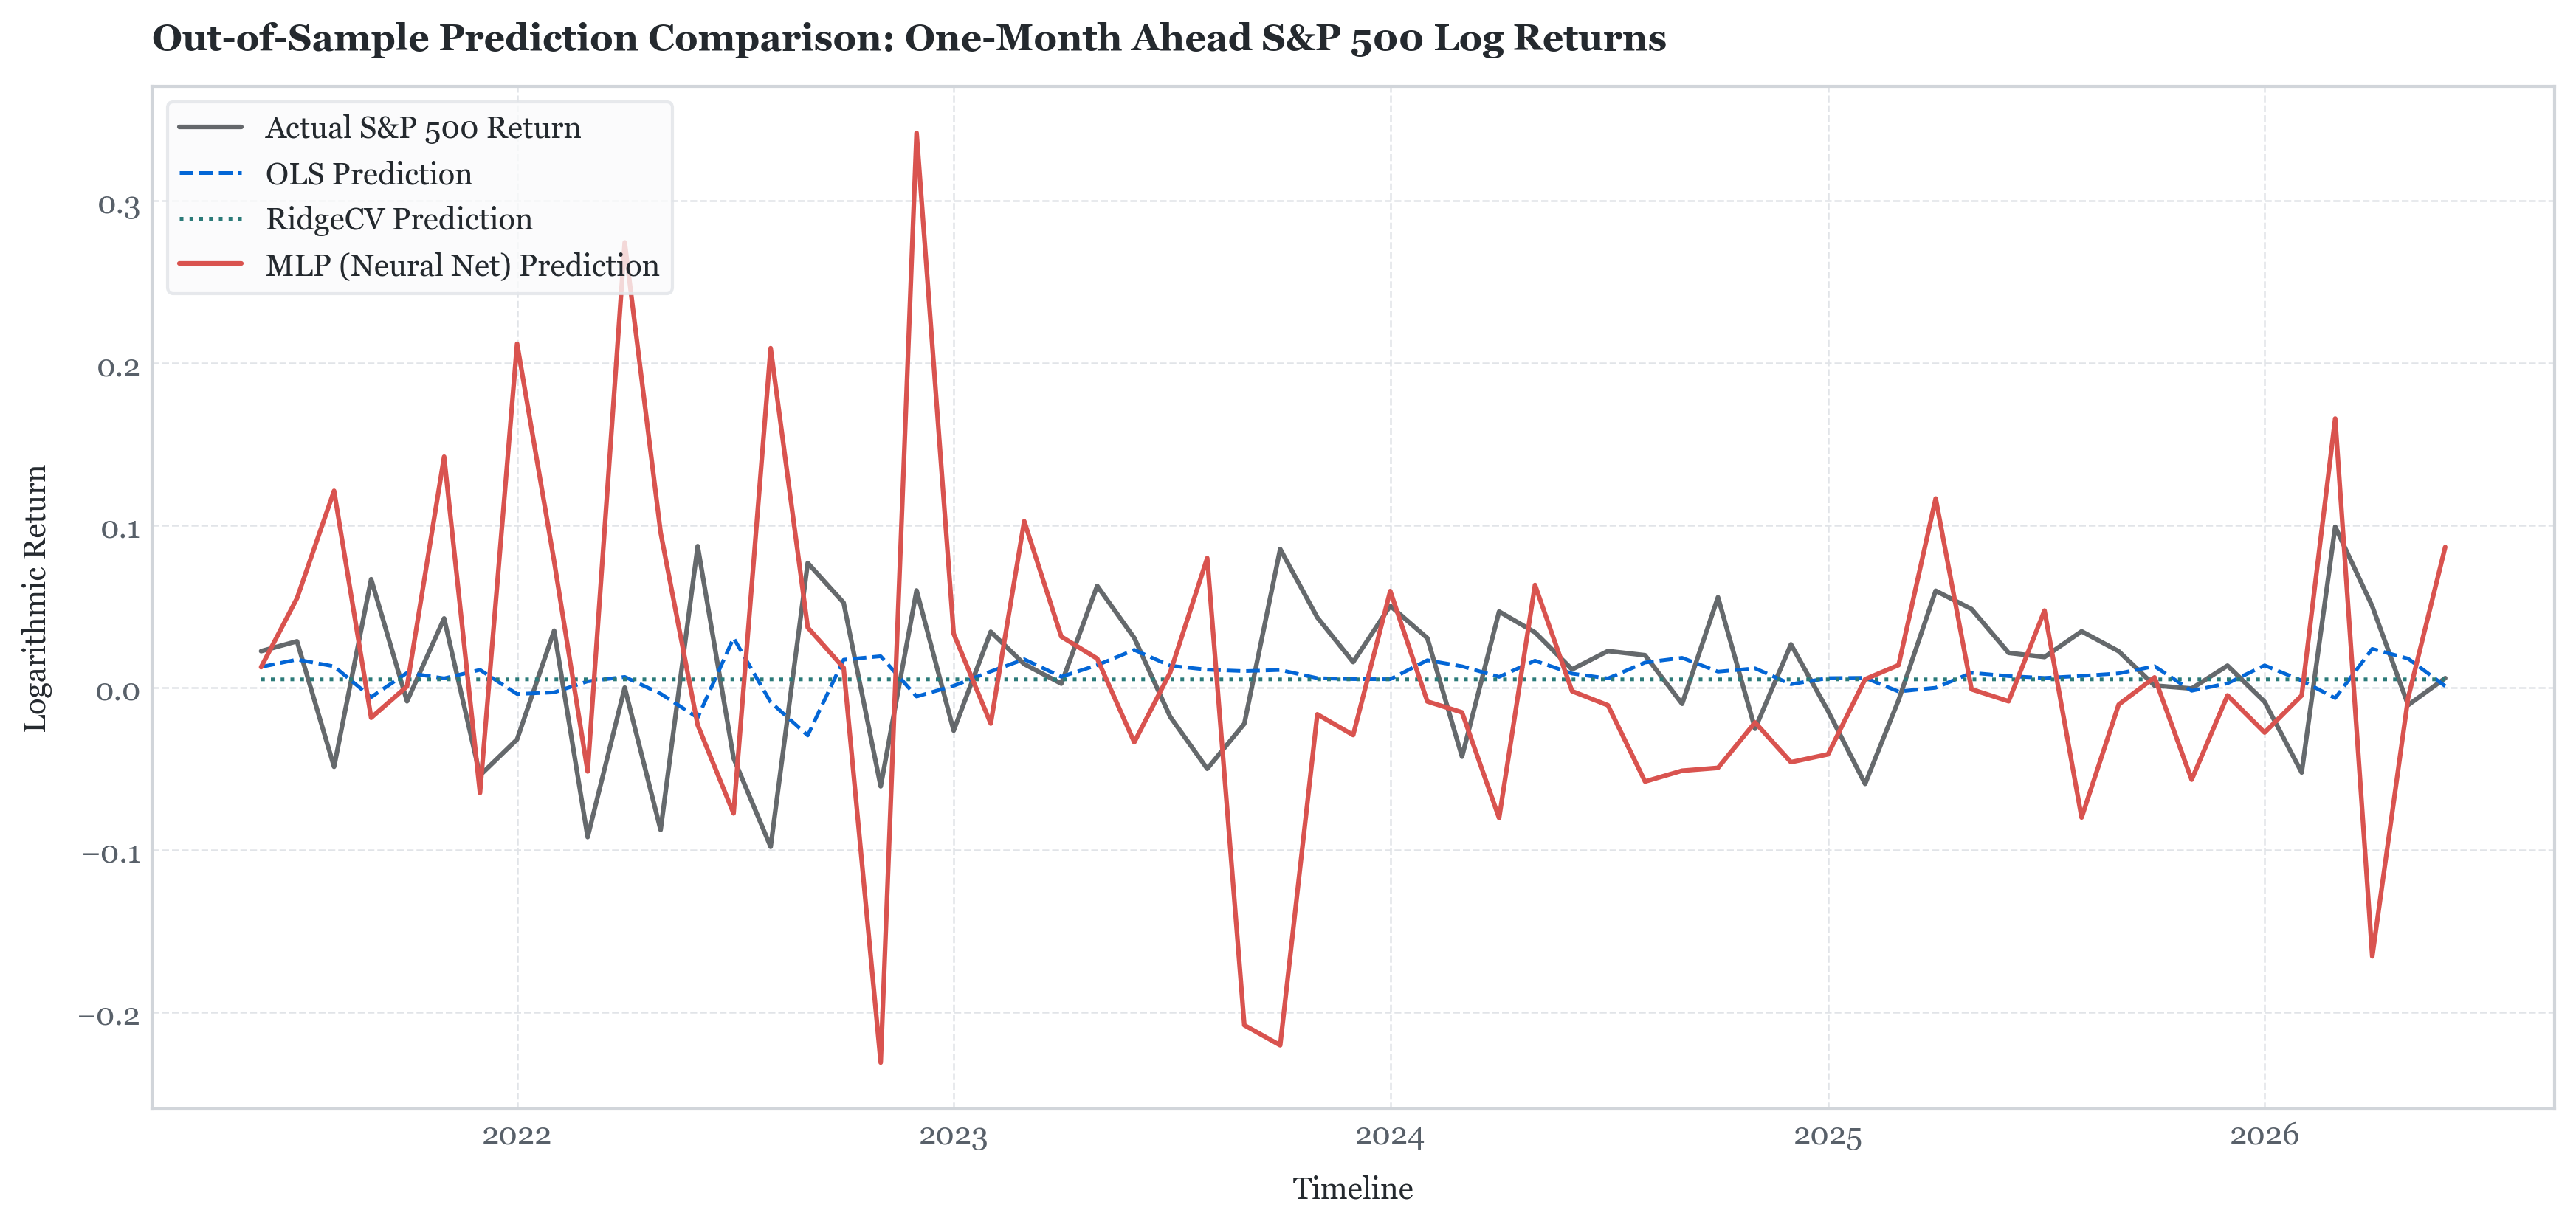

In [8]:
plt.figure(figsize=(14, 6), dpi=300)

plt.plot(df_predictions.index, df_predictions['Actual'], label='Actual S&P 500 Return', color='#24292e', linewidth=1.5, alpha=0.7)
plt.plot(df_predictions.index, df_predictions['OLS_Pred'], label='OLS Prediction', color='#0366d6', linestyle='--', linewidth=1.2)
plt.plot(df_predictions.index, df_predictions['RidgeCV_Pred'], label='RidgeCV Prediction', color='#2b7a78', linestyle=':', linewidth=1.2)
plt.plot(df_predictions.index, df_predictions['MLP_Pred'], label='MLP (Neural Net) Prediction', color='#d9534f', linewidth=1.5)

plt.title('Out-of-Sample Prediction Comparison: One-Month Ahead S&P 500 Log Returns', loc='left', fontsize=12, fontweight='bold', color='#24292e', pad=12)
plt.xlabel('Timeline', fontsize=10, labelpad=8)
plt.ylabel('Logarithmic Return', fontsize=10, labelpad=8)
plt.legend(loc='upper left', frameon=True, facecolor='#fafbfc', edgecolor='#e1e4e8')
plt.grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)

os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURES_DIR, 'model_predictions_comparison.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()


## 2.8 Residual Diagnostics
Inspect forecast errors for linear models to detect systematic bias.


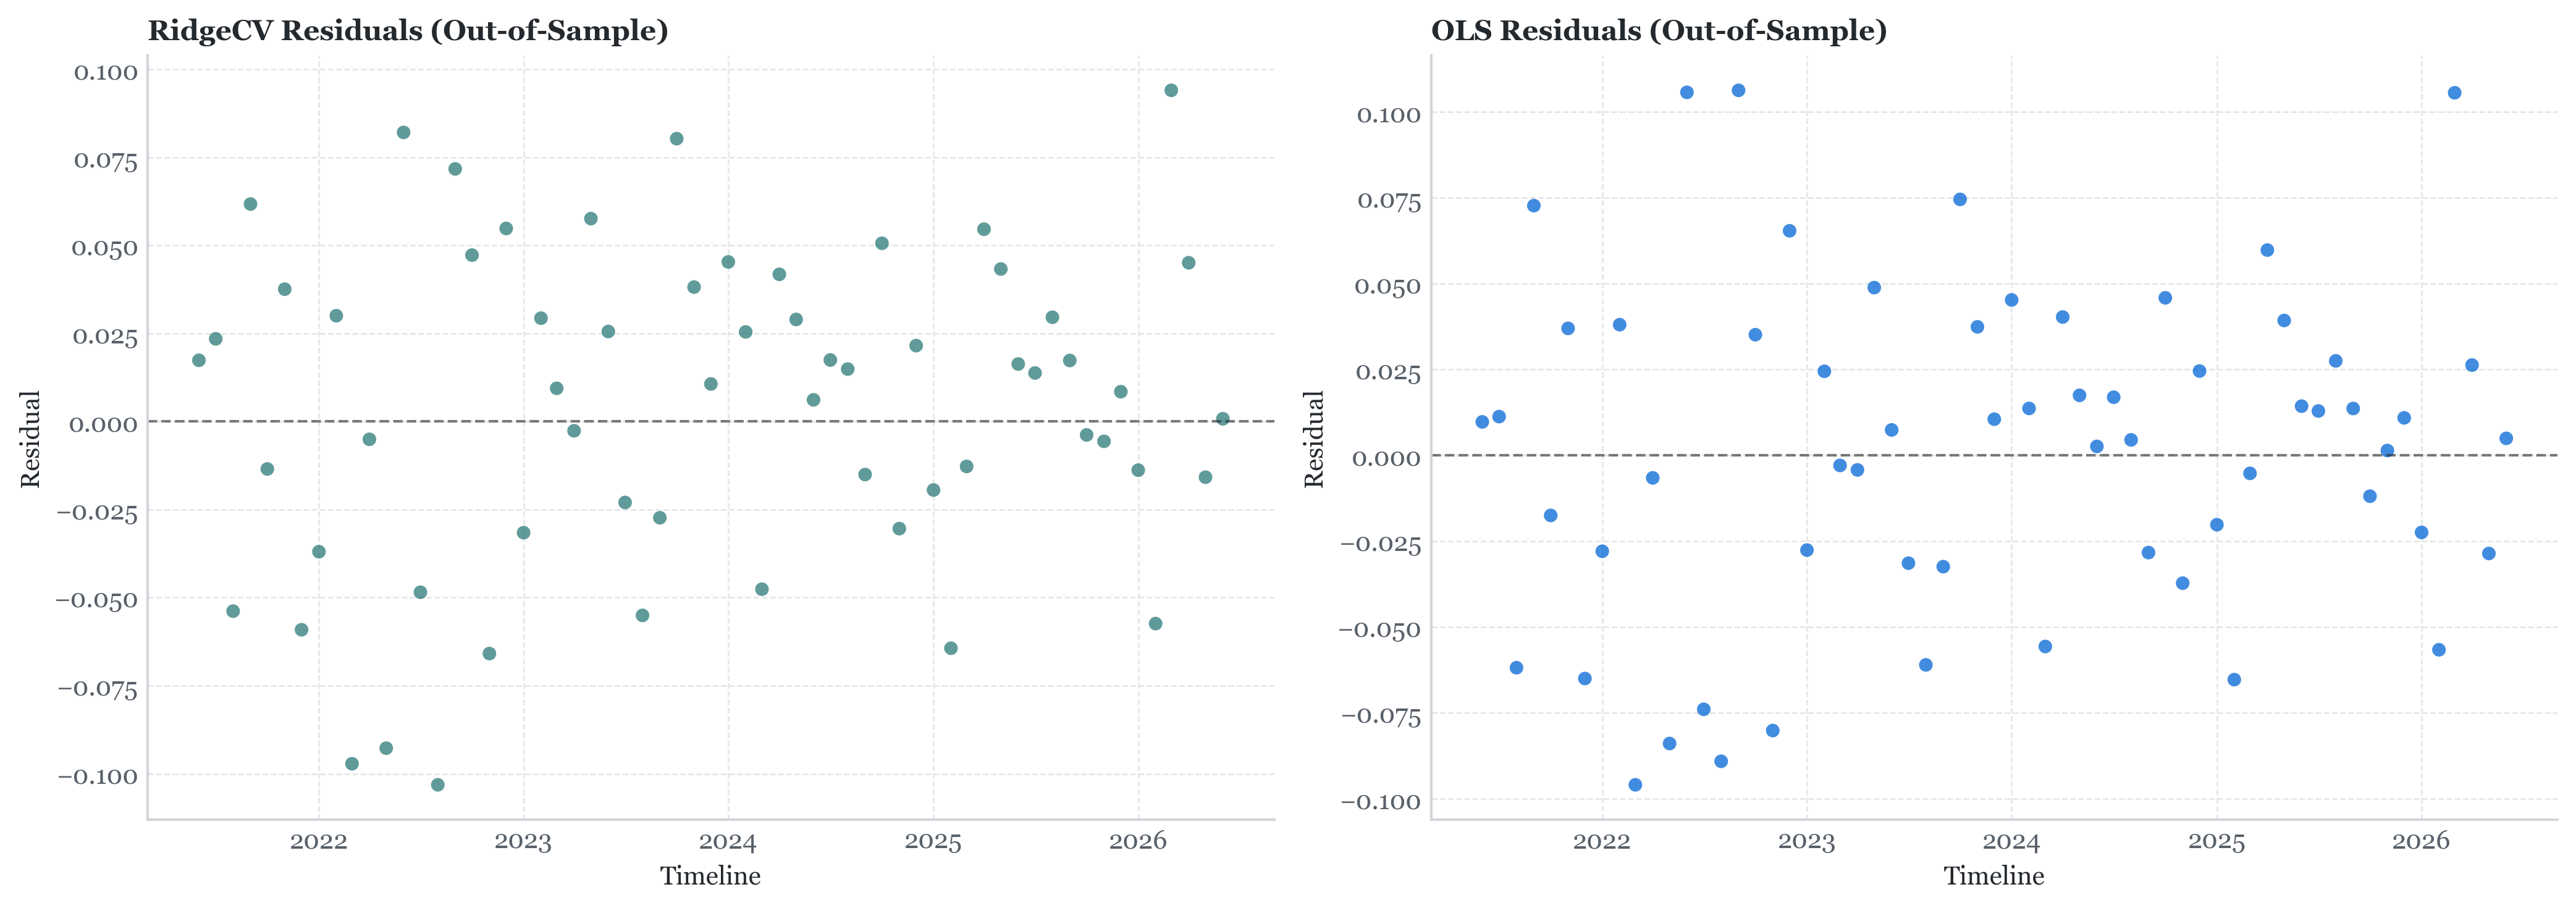

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
fig.patch.set_facecolor('#ffffff')

for ax, model_name, color in zip(axes, ['RidgeCV', 'OLS'], ['#2b7a78', '#0366d6']):
    pred_col = f'{model_name}_Pred'
    residuals = df_predictions['Actual'] - df_predictions[pred_col]
    ax.scatter(df_predictions.index, residuals, color=color, alpha=0.75, s=28, edgecolors='none')
    ax.axhline(0, color='#24292e', linewidth=1.0, linestyle='--', alpha=0.6)
    ax.set_title(f'{model_name} Residuals (Out-of-Sample)', loc='left', fontsize=11, fontweight='semibold', color='#24292e')
    ax.set_xlabel('Timeline', fontsize=10)
    ax.set_ylabel('Residual', fontsize=10)
    ax.grid(True, color='#e1e4e8', linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_forecast_residuals.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()


## 2.9 Explainable AI (XAI)
Rank macro-finance drivers via permutation importance on the MLP model.


In [10]:
from sklearn.inspection import permutation_importance

mlp_model = model_pipeline.trained_models['MLP']
result = permutation_importance(
    mlp_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

df_xai = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std,
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print('=== XAI: MLP Feature Importance (Top 10 Drivers) ===')
display(df_xai.head(10).round(5))


=== XAI: MLP Feature Importance (Top 10 Drivers) ===


,Feature,Importance_Mean,Importance_Std
0,SP500_mom_3m,1.82131,0.82055
1,SP500_vol_3m,1.81143,1.03928
2,SP500_ret,1.67021,1.20087
3,SP500_mom_12m,1.46096,1.02319
4,CPI_inflation_mom,1.10176,0.39002
5,SP500_mom_6m,0.99309,0.42849
6,T10Y2Y_diff_lag2,0.71210,0.62822
7,UNRATE_diff_lag2,0.67018,0.15031
8,UNRATE_diff_lag3,0.45155,0.25841
9,SP500_vol_12m,0.44963,0.48137


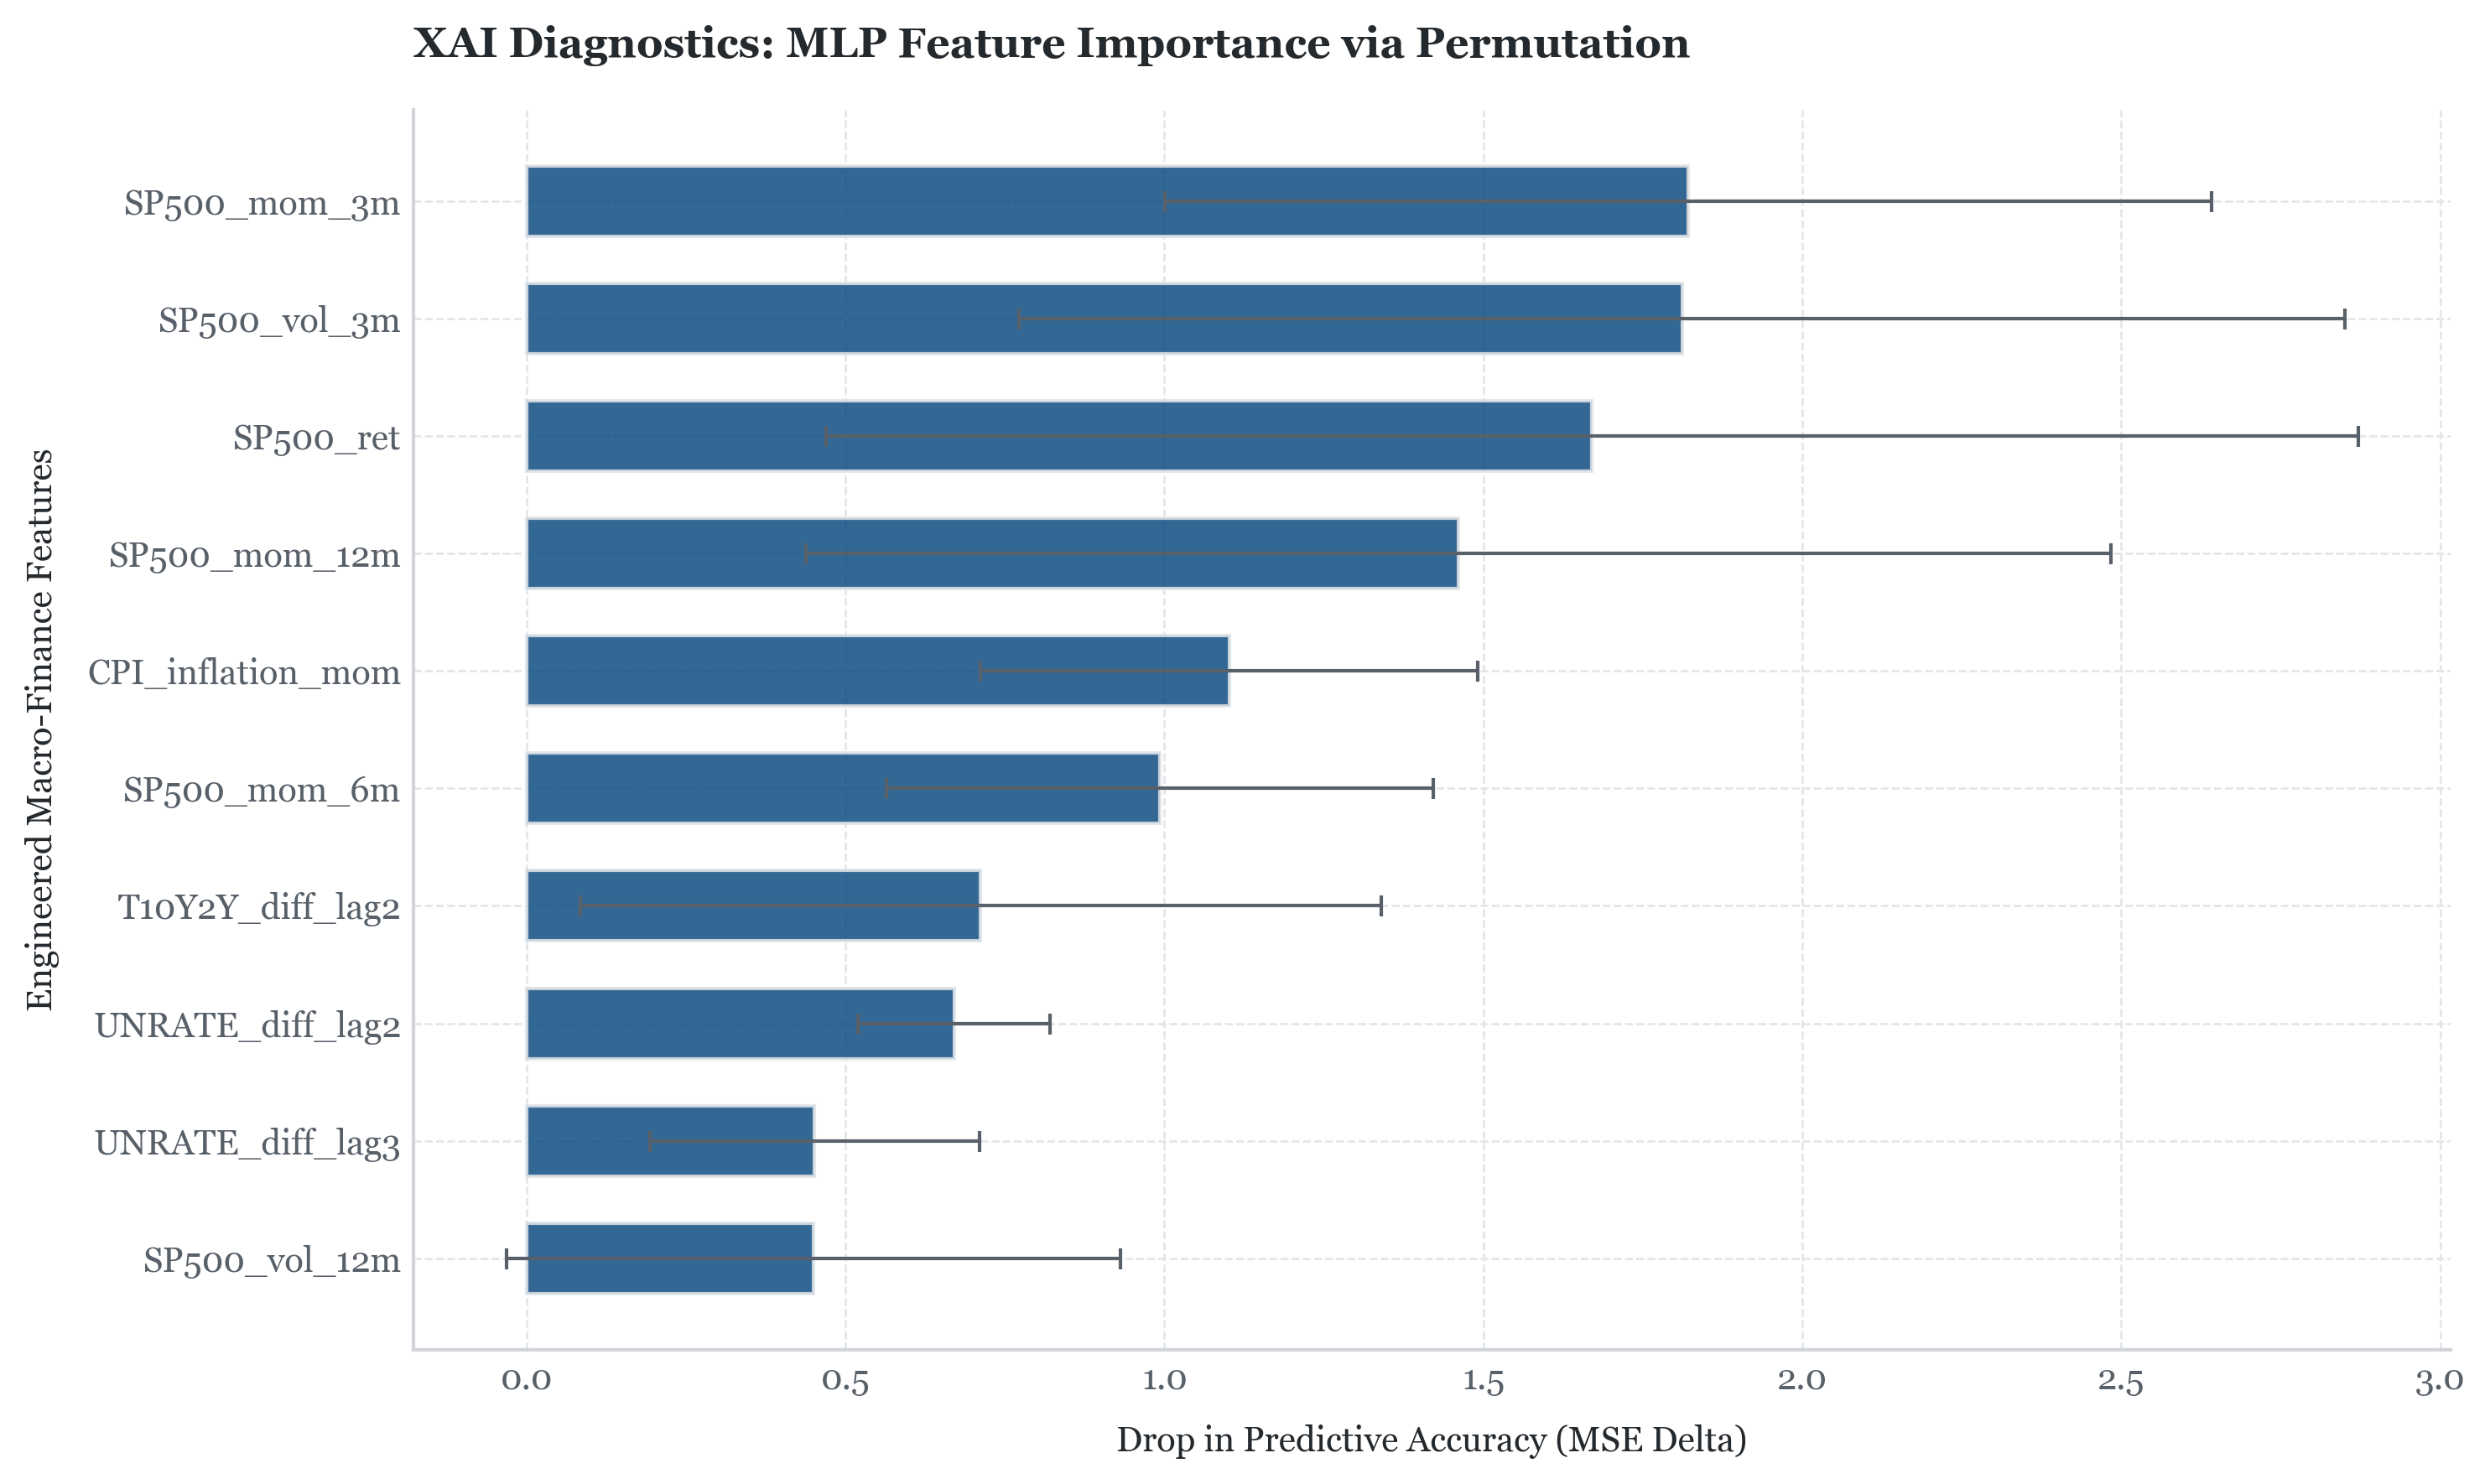

In [11]:
plt.figure(figsize=(10, 6), dpi=300)

top_xai = df_xai.head(10).sort_values(by='Importance_Mean', ascending=True)

plt.barh(top_xai['Feature'], top_xai['Importance_Mean'],
         xerr=top_xai['Importance_Std'],
         color='#0f4c81', alpha=0.85, edgecolor='#e1e4e8', height=0.6,
         error_kw={'ecolor': '#586069', 'linewidth': 1, 'capsize': 3})

plt.title('XAI Diagnostics: MLP Feature Importance via Permutation', loc='left', fontsize=12, fontweight='bold', color='#24292e', pad=15)
plt.xlabel('Drop in Predictive Accuracy (MSE Delta)', fontsize=10, labelpad=8)
plt.ylabel('Engineered Macro-Finance Features', fontsize=10, labelpad=8)
plt.grid(True, axis='x', color='#e1e4e8', linestyle='--', linewidth=0.6)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#d1d5da')
ax.spines['bottom'].set_color('#d1d5da')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'xai_feature_importance.png'), bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()
